# Purpose: Find out how to classify probe movements

# Setup & load

In [ ]:
import numpy as np                                                                                                                                                                                                                                         
import matplotlib.pyplot as plt                                                                                                                                                                                                                            
import mapd     
from mapd.kinematics import _rolling_rms, _classify_states, velocity, STATE_REST, STATE_DRIFT, STATE_MOVE
%matplotlib inline
%load_ext autoreload   
%autoreload 2


UsageError: Line magic function `%autoreload` not found.


In [3]:

T = mapd.Table('LEDFlashTriggerPiezoControl_250304_F3_C1_Table.parquet')

Found data directory: D:\Data
T = pd.read_parquet("D:\\Data\\250304\\250304_F3_C1\\LEDFlashTriggerPiezoControl_250304_F3_C1_Table.parquet")
Getting trials
Excluding trials:
[]
Getting all meta keys
['as_outcome', 'fiberLED', 'filtercube_status']
Found 2 target positions - Counter({('hi', 640.0, -280.0, 60.0): 750, ('lo', 640.0, -180.0, 60.0): 700})


In [4]:
T.df

,timestamp,background,cueDelayDurInSec,cueRampDurInSec,cueStimDurInSec,displacement,displacements,durSweep,gain,mode,...,startsample,sampratein_control,samples,tags,excluded,Trial,as_outcome,fiberLED,filtercube_status,op_cnd_blocks
trial_number,,,,,,,,,,,,,,,,,,,,,
1,2025-03-04 15:25:39.525999,5.0,0.5,0.07,0.3,-1.0,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,2070360.0,50000.0,[457464.0],"pyas target state hi: x - 360, w - 60",False,"Trial(trial=1, 250304_F3_C1, dT=9.14928, ex=Fa...",as_off,epi_only,blue,1
2,2025-03-04 15:25:48.666997,5.0,0.5,0.07,0.3,0.5,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,2527825.0,50000.0,[458024.0],"pyas target state hi: x - 360, w - 60",False,"Trial(trial=2, 250304_F3_C1, dT=9.16048, ex=Fa...",as_off,epi_only,blue,1
3,2025-03-04 15:25:57.818004,5.0,0.5,0.07,0.3,-0.5,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,2985850.0,50000.0,[441701.0],"pyas target state hi: x - 360, w - 60",False,"Trial(trial=3, 250304_F3_C1, dT=8.83402, ex=Fa...",as_off,epi_only,blue,1
4,2025-03-04 15:26:06.660000,5.0,0.5,0.07,0.3,1.0,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,3427552.0,50000.0,[478070.0],"pyas target state hi: x - 360, w - 60",False,"Trial(trial=4, 250304_F3_C1, dT=9.5614, ex=False)",as_off,epi_only,blue,1
5,2025-03-04 15:26:16.214997,5.0,0.5,0.07,0.3,0.5,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,3905623.0,50000.0,[527097.0],"pyas target state hi: x - 360, w - 60",False,"Trial(trial=5, 250304_F3_C1, dT=10.54194, ex=F...",as_off,epi_only,blue,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446,2025-03-04 19:08:23.550001,5.0,0.5,0.07,0.3,0.0,[0.0],6.5,NaN,None,...,670269531.0,50000.0,[458548.0],rest no probe pyas target state hi,False,"Trial(trial=1446, 250304_F3_C1, dT=9.17096, ex...",rest,epi_only,blue,29
1447,2025-03-04 19:08:32.740999,5.0,0.5,0.07,0.3,0.0,[0.0],6.5,NaN,None,...,670728080.0,50000.0,[423431.0],rest no probe pyas target state hi,False,"Trial(trial=1447, 250304_F3_C1, dT=8.46862, ex...",rest,epi_only,blue,29
1448,2025-03-04 19:08:41.198004,5.0,0.5,0.07,0.3,0.0,[0.0],6.5,NaN,None,...,671151512.0,50000.0,[384626.0],rest no probe pyas target state hi,False,"Trial(trial=1448, 250304_F3_C1, dT=7.69252, ex...",rest,epi_only,blue,29


# Concatenate first 200 trials into one (t, x) trace

In [5]:
trials = [tr for tr in T.df.Trial[:200] if not tr.excluded]

ts, xs = [], []
t_offset = 0.0
for tr in trials:
    idx = tr.downsample_probe
    t_raw = tr.time[idx].squeeze()
    x_raw = -(tr.probe_position[idx].squeeze() - tr.probeZero)
    if ts:
        dt = np.median(np.diff(t_raw))
        t_raw = t_raw - t_raw[0] + t_offset + dt
    t_offset = t_raw[-1]
    ts.append(t_raw)
    xs.append(x_raw)

t = np.concatenate(ts)
x = np.concatenate(xs)
fs = 1.0 / np.median(np.diff(t))
print(f"{len(trials)} trials, {len(t)} samples, fs={fs:.1f} Hz")

200 trials, 365897 samples, fs=200.0 Hz


# Smoothed speed histogram + state breakdown

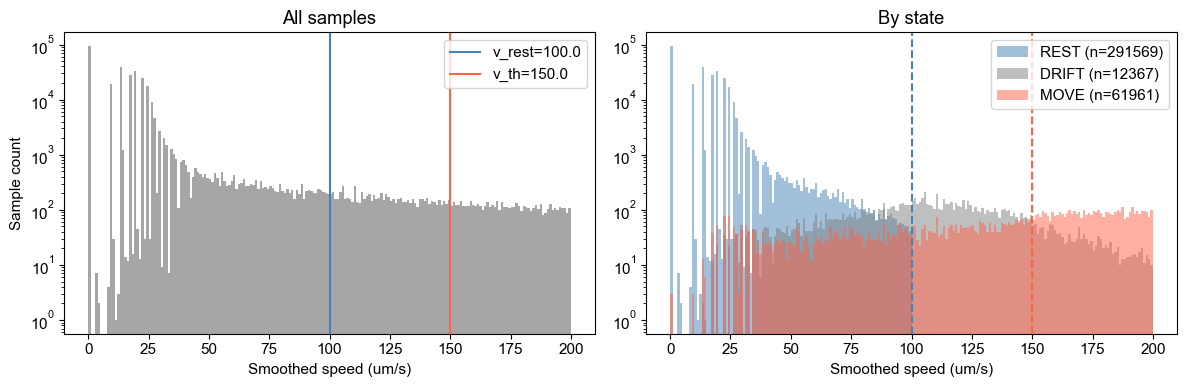

REST: 79.7%  DRIFT: 3.4%  MOVE: 16.9%


<Figure size 640x480 with 0 Axes>

In [6]:
v = velocity(t, x)
smooth_window = 0.05   # seconds — change to explore
n_smooth = max(1, int(round(smooth_window * fs)))
speed = _rolling_rms(v, n_smooth)

# Candidate thresholds — adjust these
v_th            = 150.0
v_rest          = 100.0
Dt              = 0.2
x_excursion_min = 10.0   # um — MOVE runs with smaller peak-to-peak range → DRIFT
move_gap        = 0.3   # s  — non-MOVE gaps shorter than this inside a bout → MOVE

states = _classify_states(v, x=x, v_th=v_th, v_rest=v_rest, Dt=Dt, fs=fs,
                           smooth_window=smooth_window,
                           x_excursion_min=x_excursion_min,
                           move_gap=move_gap)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full histogram of smoothed speed
ax = axes[0]
ax.hist(speed, bins=200, range=(0, 200), color='gray', alpha=0.7)
ax.axvline(v_rest, color='steelblue', lw=1.5, label=f'v_rest={v_rest}')
ax.axvline(v_th,   color='tomato',    lw=1.5, label=f'v_th={v_th}')
ax.set_xlabel('Smoothed speed (um/s)')
ax.set_ylabel('Sample count')
ax.set_title('All samples')
ax.legend()
ax.set_yscale('log')

# Right: overlaid histograms by state
ax = axes[1]
colors = {STATE_REST: 'steelblue', STATE_DRIFT: 'gray', STATE_MOVE: 'tomato'}
labels = {STATE_REST: 'REST', STATE_DRIFT: 'DRIFT', STATE_MOVE: 'MOVE'}
bins = np.linspace(0, 200, 201)
for state, color in colors.items():
    mask = states == state
    ax.hist(speed[mask], bins=bins, color=color, alpha=0.5, label=f'{labels[state]} (n={mask.sum()})')
ax.axvline(v_rest, color='steelblue', lw=1.5, ls='--')
ax.axvline(v_th,   color='tomato',    lw=1.5, ls='--')
ax.set_xlabel('Smoothed speed (um/s)')
ax.set_title('By state')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print(f"REST: {(states==STATE_REST).mean():.1%}  DRIFT: {(states==STATE_DRIFT).mean():.1%}  MOVE: {(states==STATE_MOVE).mean():.1%}")

plt.savefig("Notes/speed_histogram.png", dpi=150, bbox_inches='tight')

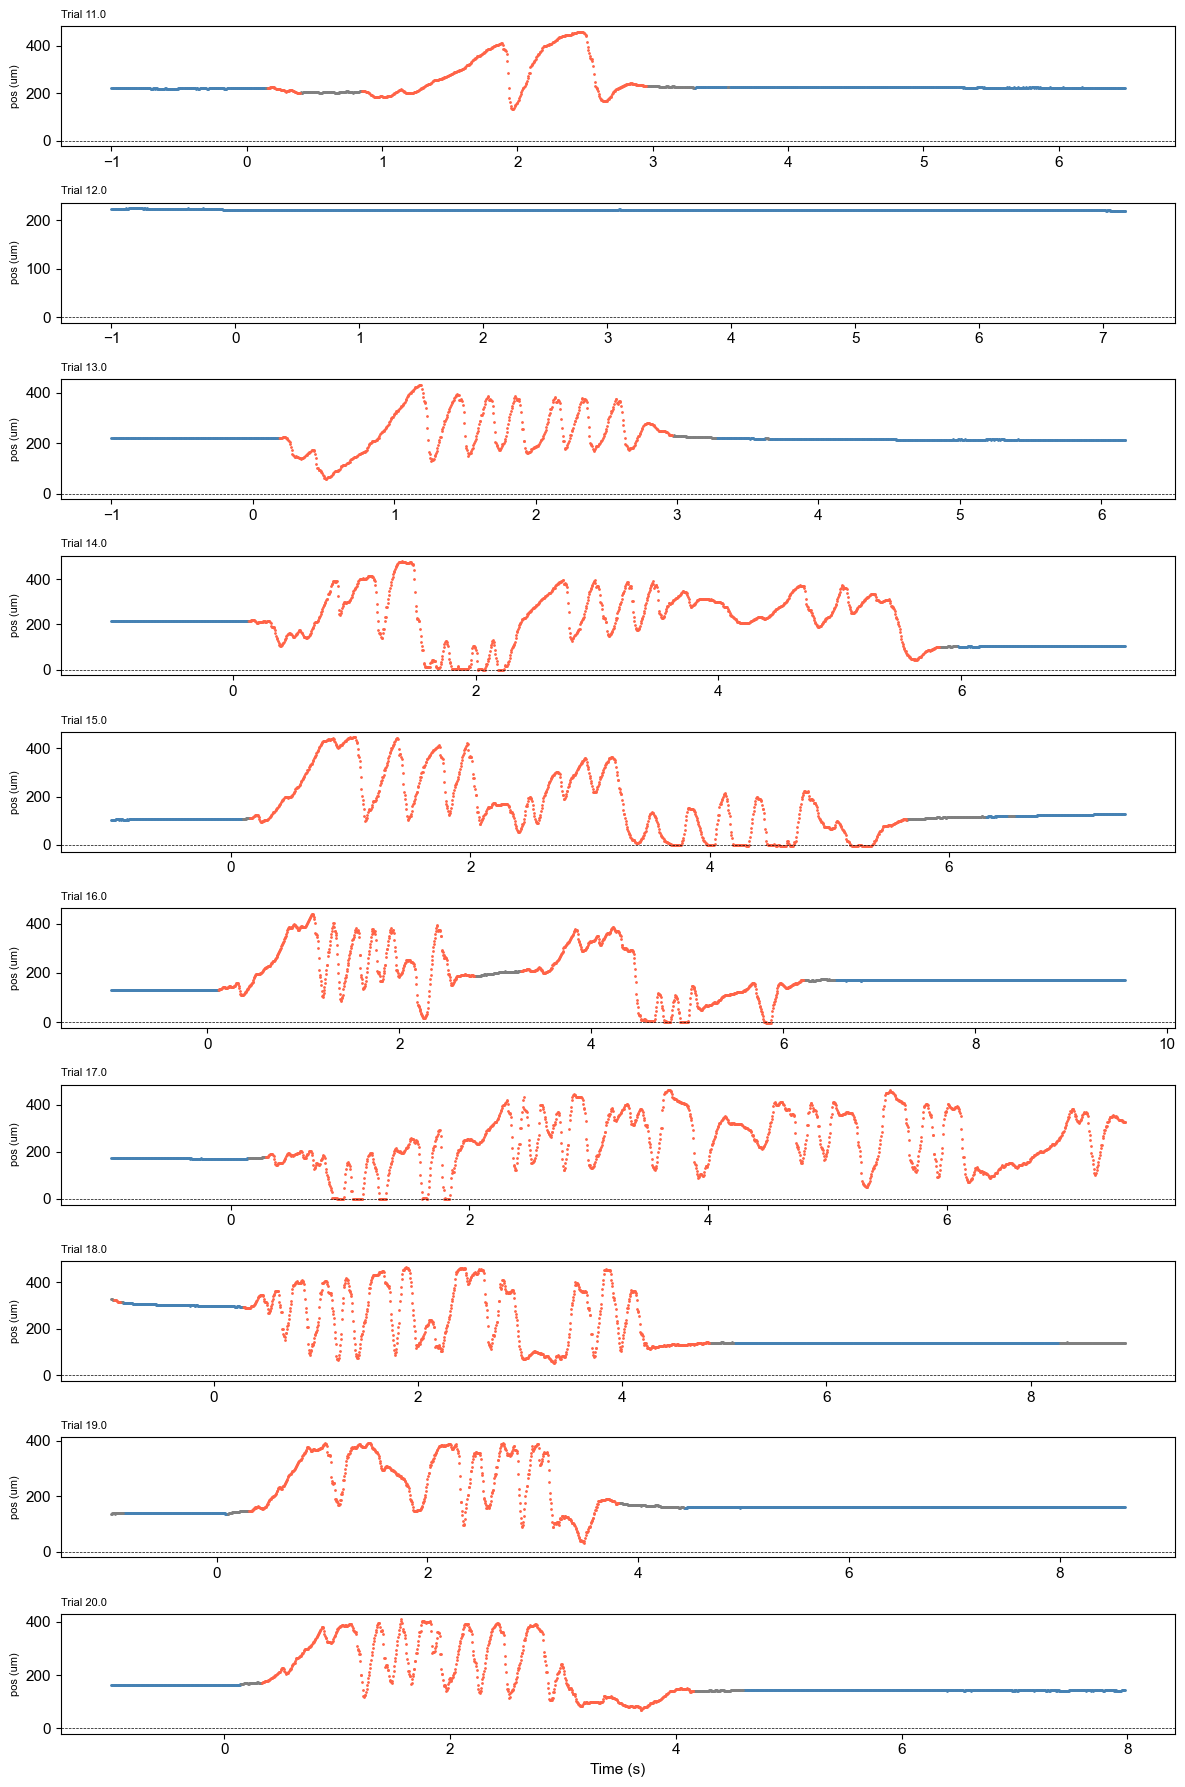

In [15]:
# Plot first 10 trials — position trace colored by state

# Candidate thresholds — adjust these
v_th            = 120.0
v_rest          = 80.0
Dt              = 0.2
x_excursion_min = 8.0   # um — MOVE runs with smaller peak-to-peak range → DRIFT
move_gap        = 0.3   # s  — non-MOVE gaps shorter than this inside a bout → MOVE

tr_start  = 10
n_plot = 10                                                                                                                                                                                             
fig, axes = plt.subplots(n_plot, 1, figsize=(12, 1.8 * n_plot), sharex=False)
colors = {STATE_REST: 'steelblue', STATE_DRIFT: 'gray', STATE_MOVE: 'tomato'}

for ax, tr in zip(axes, trials[tr_start:tr_start+n_plot]):
    idx = tr.downsample_probe
    t_tr = tr.time[idx].squeeze()
    x_tr = -(tr.probe_position[idx].squeeze() - tr.probeZero)

    v_tr = velocity(t_tr, x_tr)
    fs_tr = 1.0 / np.median(np.diff(t_tr))
    st_tr = _classify_states(v_tr, x=x_tr, v_th=v_th, v_rest=v_rest, Dt=Dt,
                              fs=fs_tr, smooth_window=smooth_window,
                              x_excursion_min=x_excursion_min,
                              move_gap=move_gap)

    for state, color in colors.items():
        mask = st_tr == state
        ax.scatter(t_tr[mask], x_tr[mask], s=1, c=color, rasterized=True)

    ax.set_ylabel('pos (um)', fontsize=8)
    ax.set_title(f'Trial {tr.params["trial"]}', fontsize=8, loc='left')
    ax.axhline(0, color='k', lw=0.5, ls='--')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig("Notes/trial_states.png", dpi=150, bbox_inches='tight')
plt.show()

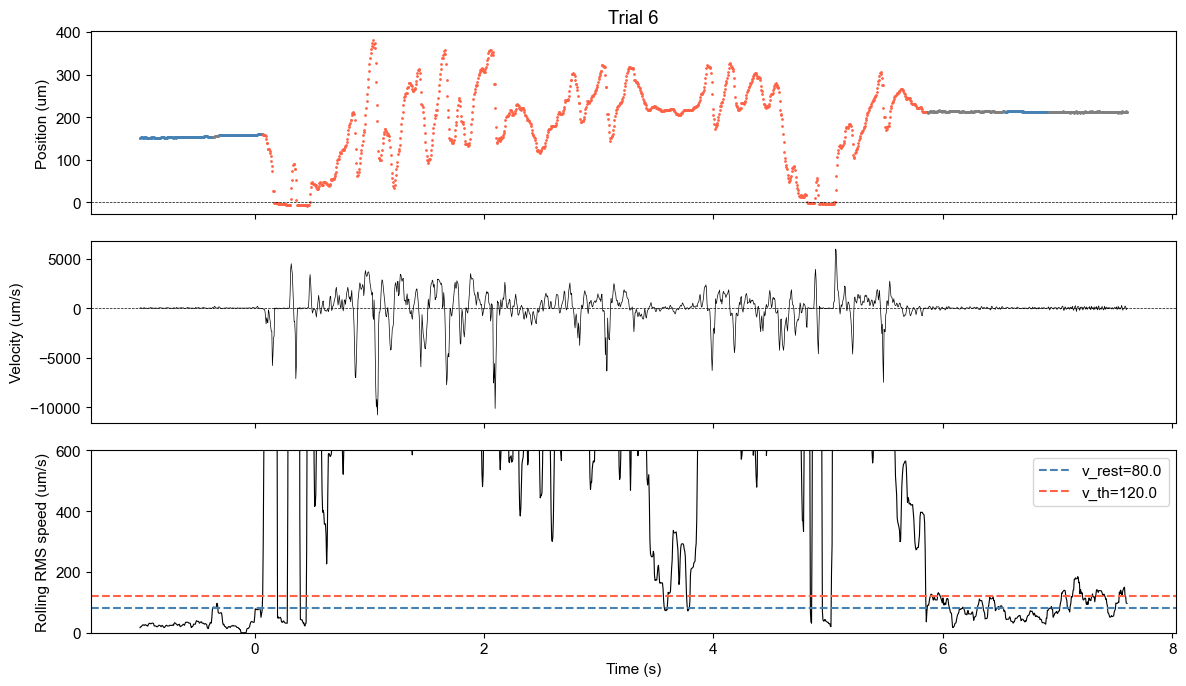

In [16]:
# Focus on trial 6 — position, velocity, and rolling RMS with thresholds
tr6 = trials[5]
idx = tr6.downsample_probe
t6  = tr6.time[idx].squeeze()
x6  = -(tr6.probe_position[idx].squeeze() - tr6.probeZero)

v6    = velocity(t6, x6)
fs6   = 1.0 / np.median(np.diff(t6))
n_sm  = max(1, int(round(smooth_window * fs6)))
spd6  = _rolling_rms(v6, n_sm)
st6   = _classify_states(v6, x=x6, v_th=v_th, v_rest=v_rest, Dt=Dt,
                          fs=fs6, smooth_window=smooth_window,
                          x_excursion_min=x_excursion_min,
                          move_gap=move_gap)

colors = {STATE_REST: 'steelblue', STATE_DRIFT: 'gray', STATE_MOVE: 'tomato'}

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

# --- Position colored by state ---
ax = axes[0]
for state, color in colors.items():
    mask = st6 == state
    ax.scatter(t6[mask], x6[mask], s=1, c=color, rasterized=True)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('Position (um)')
ax.set_title('Trial 6')

# --- Raw velocity ---
ax = axes[1]
ax.plot(t6, v6, color='k', lw=0.5)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('Velocity (um/s)')

# --- Rolling RMS speed with thresholds ---
ax = axes[2]
ax.plot(t6, spd6, color='k', lw=0.8)
ax.axhline(v_rest, color='steelblue', lw=1.5, ls='--', label=f'v_rest={v_rest}')
ax.axhline(v_th,   color='tomato',    lw=1.5, ls='--', label=f'v_th={v_th}')
ax.set_ylabel('Rolling RMS speed (um/s)')
ax.set_xlabel('Time (s)')
ax.set_ylim([0,5*v_th])
ax.legend()

plt.tight_layout()
plt.savefig("Notes/trial6_detail.png", dpi=150, bbox_inches='tight')
plt.show()